In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files
file = files.upload()

Saving Heart_Disease_Prediction.csv to Heart_Disease_Prediction.csv


In [3]:
df = pd.read_csv("Heart_Disease_Prediction.csv")

In [4]:
df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


In [5]:
df.shape

(270, 14)

In [6]:
df.columns

Index(['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120',
       'EKG results', 'Max HR', 'Exercise angina', 'ST depression',
       'Slope of ST', 'Number of vessels fluro', 'Thallium', 'Heart Disease'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    object 
dtypes: float64(1), int64(12), 

In [8]:
df.describe()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,3.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,1.585185,0.670370,4.696296
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,1.940659
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,1.000000,0.000000,3.000000
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,1.000000,0.000000,3.000000
50%,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,2.000000,0.000000,3.000000
75%,61.000000,1.000000,4.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,3.000000,3.000000,7.000000


In [9]:
df.isnull().sum()

,0
Age,0
Sex,0
Chest pain type,0
BP,0
Cholesterol,0
FBS over 120,0
EKG results,0
Max HR,0
Exercise angina,0
ST depression,0


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df["Heart Disease"].value_counts()

,count
Heart Disease,
Absence,150
Presence,120


/tmp/ipykernel_3554/2275891670.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Heart Disease', data=df, palette='Set2')


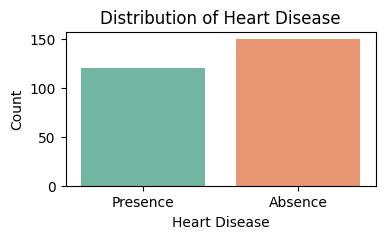

In [12]:
plt.figure(figsize=(4,2))
sns.countplot(x='Heart Disease', data=df, palette='Set2')
plt.title("Distribution of Heart Disease")
plt.xlabel("Heart Disease")
plt.ylabel("Count")
plt.show()

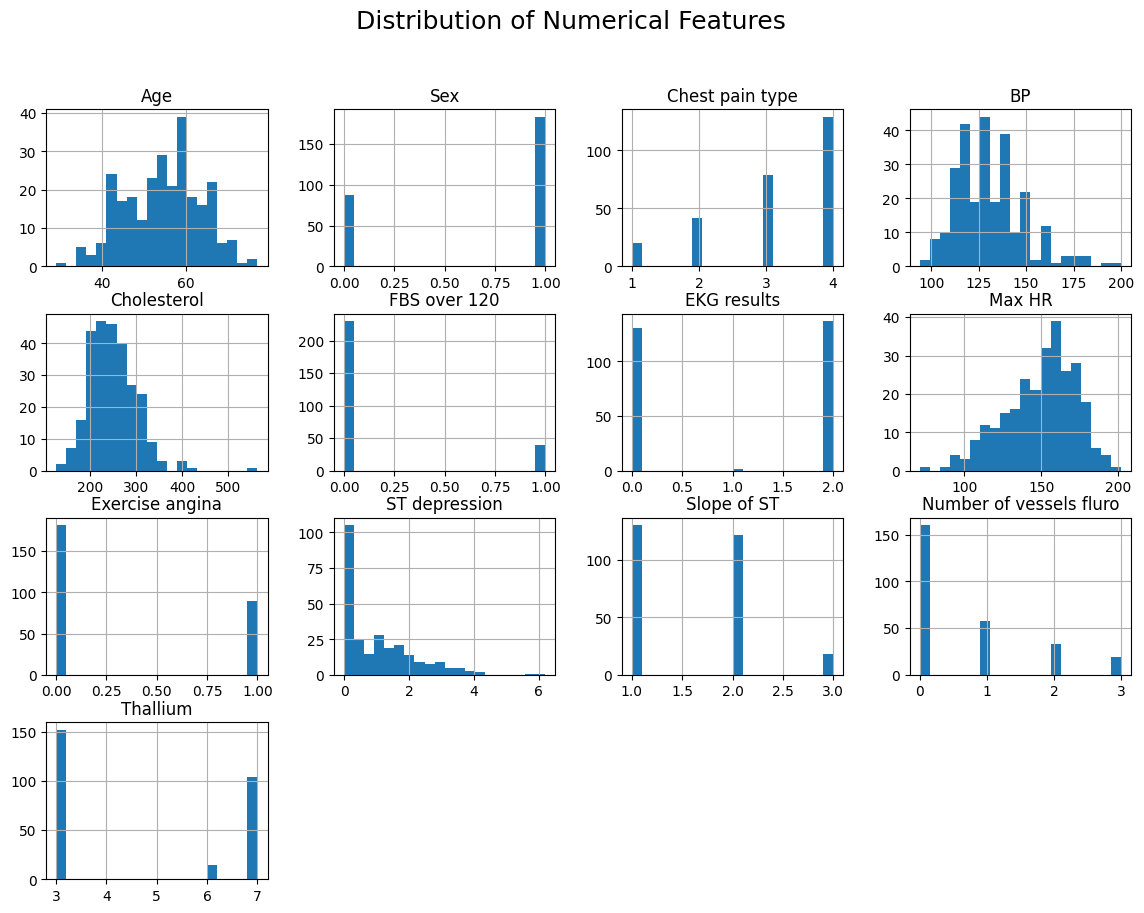

In [13]:
df.hist(figsize=(14,10), bins=20)
plt.suptitle("Distribution of Numerical Features", fontsize=18)
plt.show()

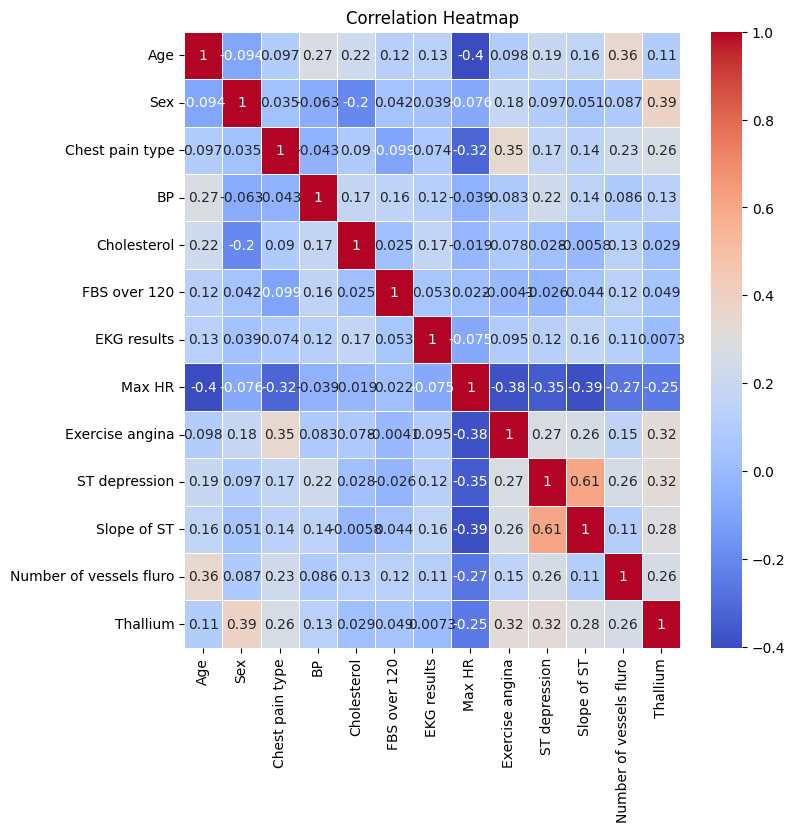

In [14]:
plt.figure(figsize=(8,8))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm',
            linewidths=0.5)

plt.title("Correlation Heatmap")
plt.show()

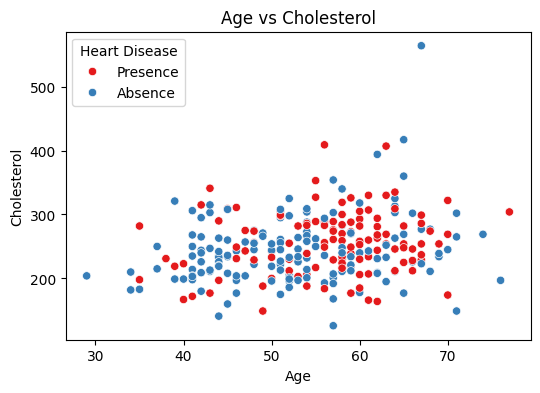

In [15]:
plt.figure(figsize=(6,4))

sns.scatterplot(
    x='Age',
    y='Cholesterol',
    hue='Heart Disease',
    data=df,
    palette='Set1'
)
plt.title("Age vs Cholesterol")
plt.show()

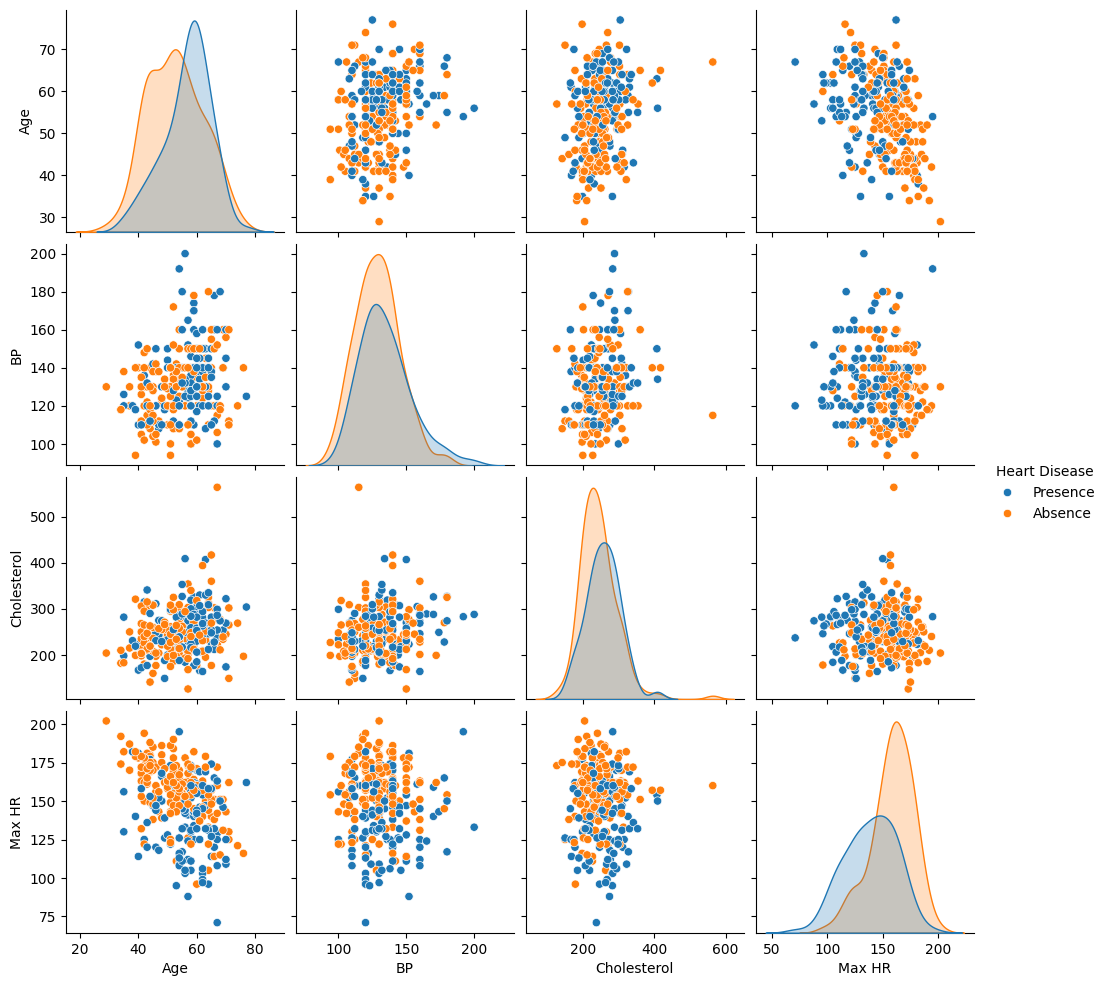

In [16]:
selected_features = ['Age',
                     'BP',
                     'Cholesterol',
                     'Max HR',
                     'Heart Disease']

sns.pairplot(df[selected_features],
             hue='Heart Disease')

plt.show()

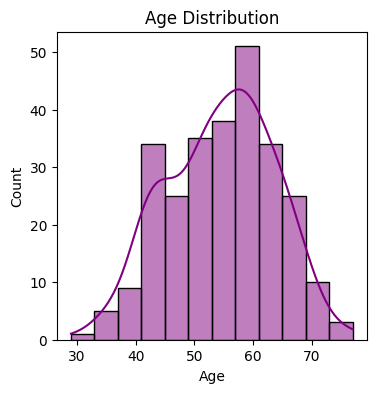

In [17]:
plt.figure(figsize=(4,4))
sns.histplot(df['Age'],
             kde=True,
             color='purple')
plt.title("Age Distribution")
plt.show()

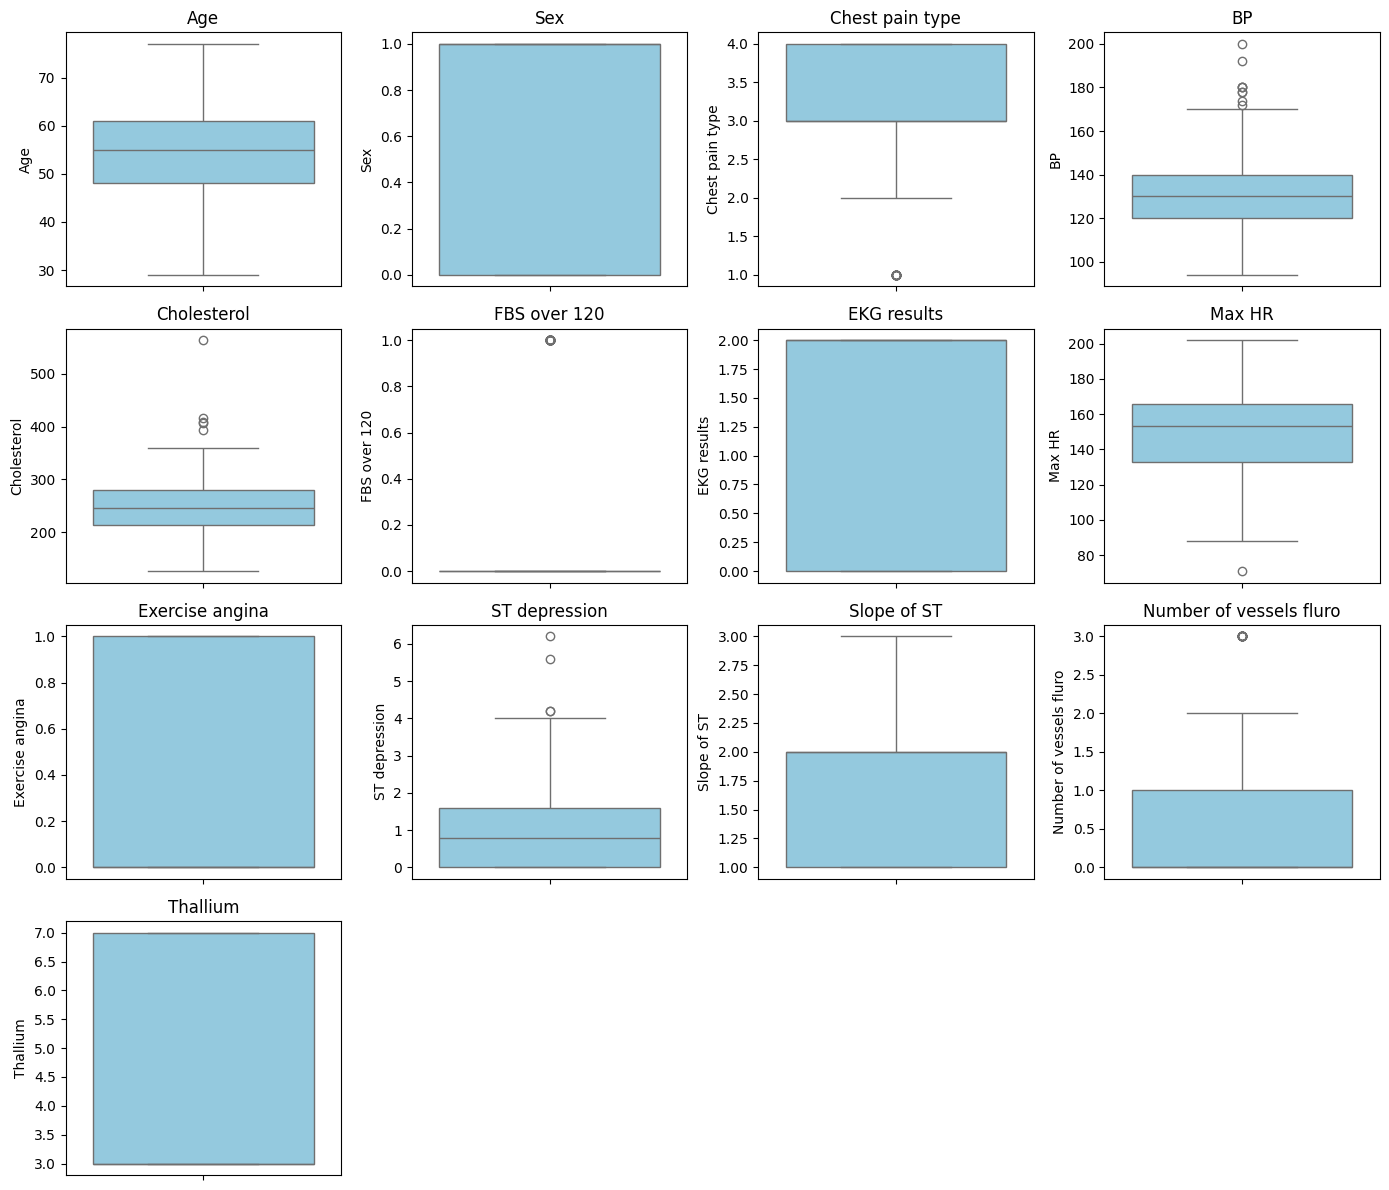

In [18]:
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns
plt.figure(figsize=(14,12))

for i, col in enumerate(numerical_columns):
    plt.subplot(4, 4, i+1)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(col)

plt.tight_layout()
plt.show()

In [19]:
for col in numerical_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers")

Age: 0 outliers
Sex: 0 outliers
Chest pain type: 20 outliers
BP: 9 outliers
Cholesterol: 5 outliers
FBS over 120: 40 outliers
EKG results: 0 outliers
Max HR: 1 outliers
Exercise angina: 0 outliers
ST depression: 4 outliers
Slope of ST: 0 outliers
Number of vessels fluro: 19 outliers
Thallium: 0 outliers


In [20]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["Heart Disease"] = le.fit_transform(df["Heart Disease"])
df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,1
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,0
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,1
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,0
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,0


In [21]:
X = df.drop("Heart Disease", axis=1)
y = df["Heart Disease"]

print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

Features Shape : (270, 13)
Target Shape : (270,)


In [22]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("Training Data :", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data : (216, 13)
Testing Data : (54, 13)


In [23]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [24]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

In [25]:
print("Before SMOTE")
print(y_train.value_counts())
print("\nAfter SMOTE")
print(pd.Series(y_train_smote).value_counts())

Before SMOTE
Heart Disease
0    120
1     96
Name: count, dtype: int64

After SMOTE
Heart Disease
0    120
1    120
Name: count, dtype: int64


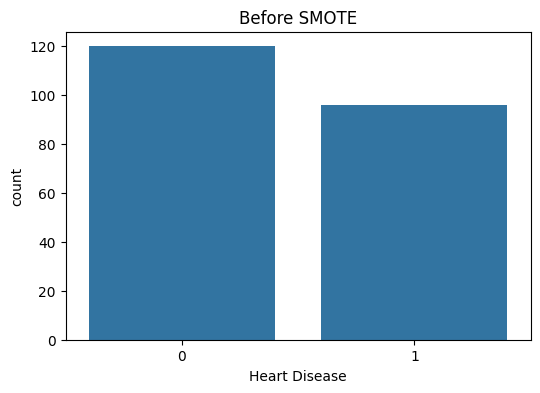

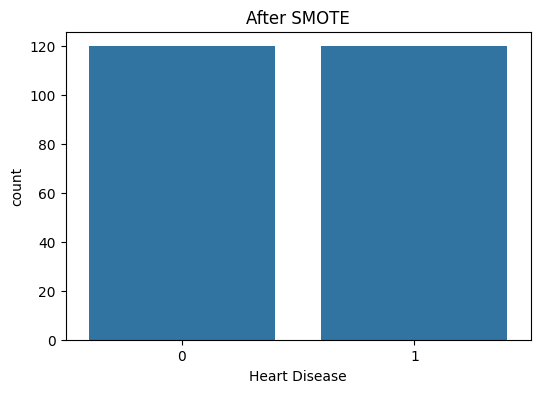

In [26]:
plt.figure(figsize=(6,4))
sns.countplot(x=y_train)
plt.title("Before SMOTE")
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(x=pd.Series(y_train_smote))
plt.title("After SMOTE")
plt.show()

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

In [28]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(random_state=42)
}

KNN

In [29]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_smote, y_train_smote)

KNeighborsClassifier()

In [30]:
y_pred_knn = knn.predict(X_test_scaled)

In [31]:
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print("Accuracy :", accuracy_knn)

Accuracy : 0.7592592592592593


[[20 10]
 [ 3 21]]


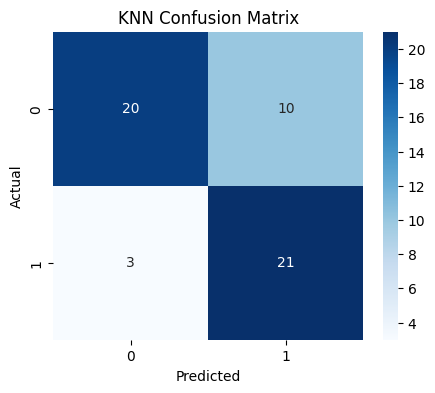

In [32]:
cm_knn = confusion_matrix(y_test, y_pred_knn)
print(cm_knn)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm_knn,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN Confusion Matrix")
plt.show()

In [33]:
precision_knn = precision_score(y_test, y_pred_knn, pos_label=1)
print("Precision :", precision_knn)

recall_knn = recall_score(y_test, y_pred_knn, pos_label=1)
print("Recall :", recall_knn)

f1_knn = f1_score(y_test, y_pred_knn, pos_label=1)
print("F1 Score :", f1_knn)

Precision : 0.6774193548387096
Recall : 0.875
F1 Score : 0.7636363636363637


In [34]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.87      0.67      0.75        30
           1       0.68      0.88      0.76        24

    accuracy                           0.76        54
   macro avg       0.77      0.77      0.76        54
weighted avg       0.78      0.76      0.76        54



In [35]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_neighbors': [3,5,7,9,11],
    'weights': ['uniform','distance'],
    'metric': ['euclidean','manhattan']
}
grid_knn = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_knn.fit(X_train_smote, y_train_smote)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'metric': ['euclidean', 'manhattan'],
                         'n_neighbors': [3, 5, 7, 9, 11],
                         'weights': ['uniform', 'distance']},
             scoring='accuracy')

In [36]:
print("Best Parameters:")
print(grid_knn.best_params_)

print("Best Accuracy:")
print(grid_knn.best_score_)

best_knn = grid_knn.best_estimator_
best_pred_knn = best_knn.predict(X_test_scaled)

print("Final Accuracy :", accuracy_score(y_test, best_pred_knn))

Best Parameters:
{'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'distance'}
Best Accuracy:
0.8625
Final Accuracy : 0.7592592592592593


Decision Tree

In [37]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_smote, y_train_smote)

DecisionTreeClassifier(random_state=42)

In [38]:
y_pred_dt = dt.predict(X_test_scaled)

In [39]:
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print("Accuracy:", accuracy_dt)

Accuracy: 0.8333333333333334


[[25  5]
 [ 4 20]]


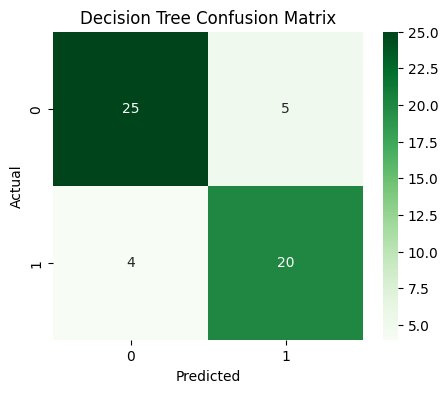

In [40]:
cm_dt = confusion_matrix(y_test, y_pred_dt)
print(cm_dt)
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(5,4))
sns.heatmap(
    cm_dt,
    annot=True,
    fmt='d',
    cmap='Greens'
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")
plt.show()

In [41]:
precision_dt = precision_score(y_test, y_pred_dt, pos_label = 1)
print("Precision:", precision_dt)

recall_dt = recall_score(y_test, y_pred_dt, pos_label=1)
print("Recall:", recall_dt)

f1_dt = f1_score(y_test, y_pred_dt, pos_label=1)
print("F1 Score:", f1_dt)

Precision: 0.8
Recall: 0.8333333333333334
F1 Score: 0.8163265306122449


In [42]:
from sklearn.model_selection import GridSearchCV
param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_dt = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid_dt,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_dt.fit(X_train_smote, y_train_smote)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 5, 10, 15, 20],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             scoring='accuracy')

In [43]:
print("Best Parameters:")
print(grid_dt.best_params_)

print("Best CV Accuracy:")
print(grid_dt.best_score_)

best_dt = grid_dt.best_estimator_
best_pred_dt = best_dt.predict(X_test_scaled)
print("Final Accuracy:", accuracy_score(y_test, best_pred_dt))

Best Parameters:
{'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 2}
Best CV Accuracy:
0.8375
Final Accuracy: 0.7962962962962963


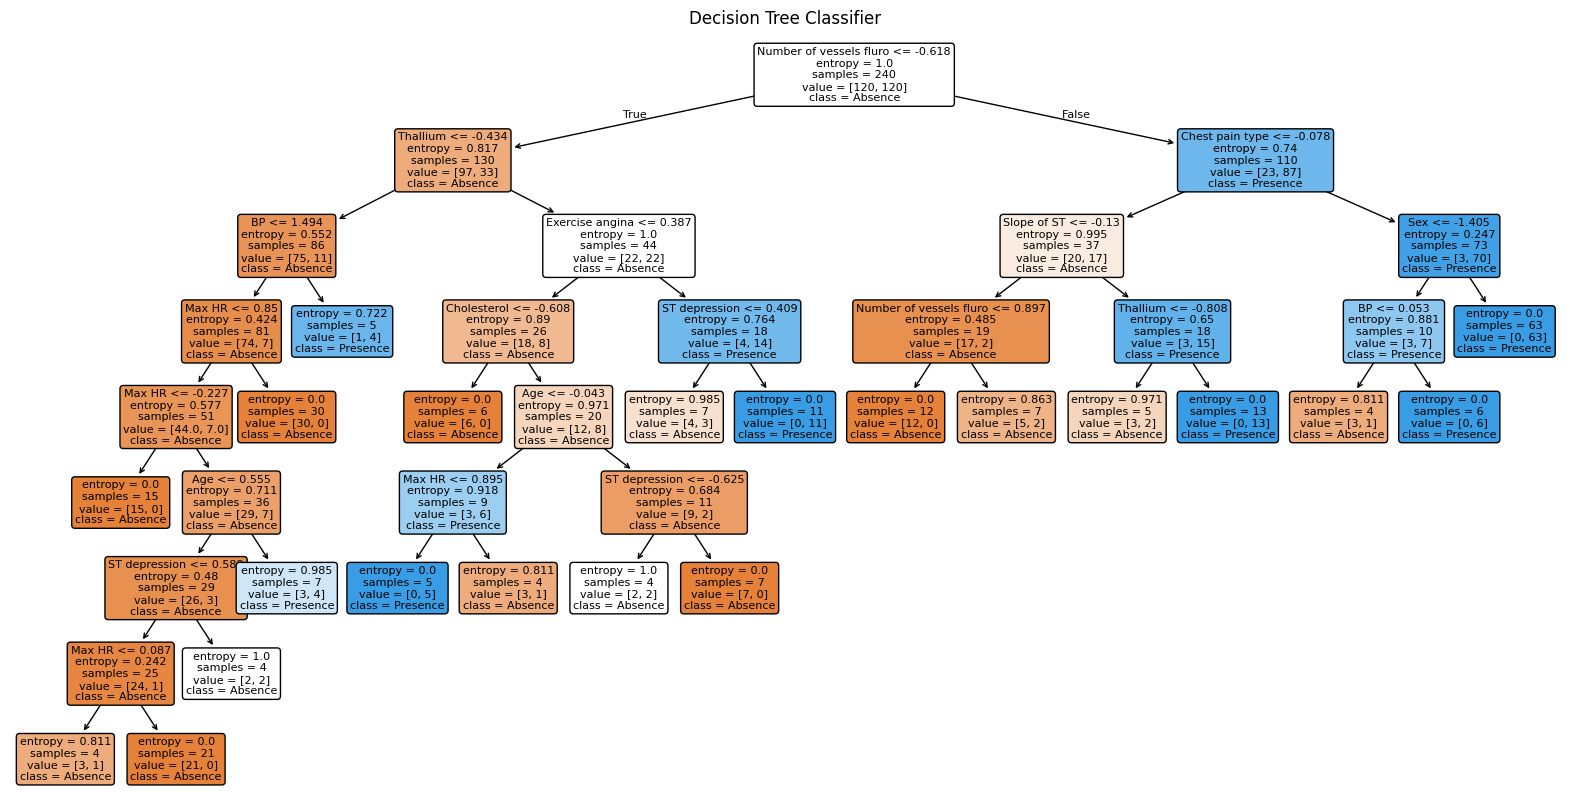

In [44]:
from sklearn.tree import plot_tree
plt.figure(figsize=(20,10))

best_dt = grid_dt.best_estimator_
plot_tree(
    best_dt,
    feature_names=X.columns,
    class_names=['Absence', 'Presence'], # Corrected from df['Heart Disease'].unique()
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Decision Tree Classifier")
plt.show()

Random Forest Classifier

In [45]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_smote, y_train_smote)

RandomForestClassifier(random_state=42)

In [46]:
y_pred_rf = rf.predict(X_test_scaled)

In [47]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print("Accuracy:", accuracy_rf)

Accuracy: 0.8333333333333334


[[25  5]
 [ 4 20]]


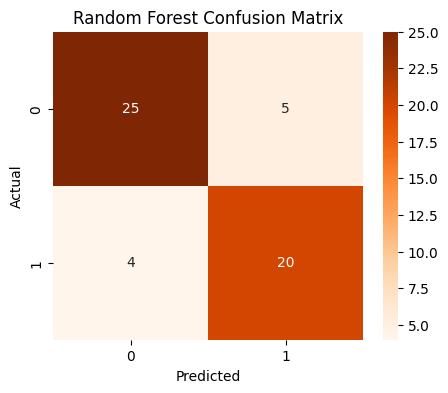

In [48]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
print(cm_rf)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Oranges'
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

In [49]:
precision_rf = precision_score(y_test, y_pred_rf, pos_label=1)
print("Precision:", precision_rf)

recall_rf = recall_score(y_test, y_pred_rf, pos_label=1)
print("Recall:", recall_rf)

f1_rf = f1_score(y_test, y_pred_rf, pos_label=1)
print("F1 Score:", f1_rf)

Precision: 0.8
Recall: 0.8333333333333334
F1 Score: 0.8163265306122449


In [51]:
from sklearn.model_selection import GridSearchCV
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid_rf,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_rf.fit(X_train_smote, y_train_smote)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 10, 20, 30],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='accuracy')

In [52]:
print("Best Parameters:")
print(grid_rf.best_params_)

print("Best CV Accuracy:")
print(grid_rf.best_score_)

best_rf = grid_rf.best_estimator_
best_pred_rf = best_rf.predict(X_test_scaled)
print("Final Accuracy:", accuracy_score(y_test, best_pred_rf))

Best Parameters:
{'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best CV Accuracy:
0.8583333333333334
Final Accuracy: 0.8333333333333334


Logistic Regression

In [53]:
lr = LogisticRegression(random_state=42)
lr.fit(X_train_smote, y_train_smote)

LogisticRegression(random_state=42)

In [54]:
y_pred_lr = lr.predict(X_test_scaled)

In [55]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print("Accuracy:", accuracy_lr)

Accuracy: 0.8518518518518519


[[24  6]
 [ 2 22]]


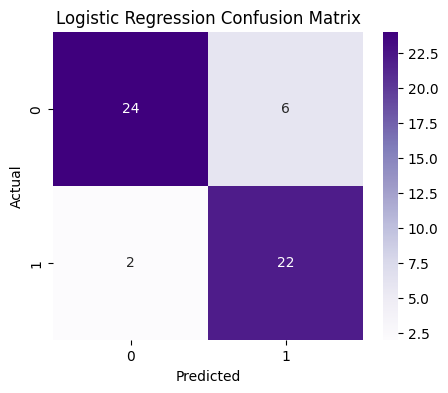

In [56]:
cm_lr = confusion_matrix(y_test, y_pred_lr)
print(cm_lr)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Purples'
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [57]:
precision_lr = precision_score(y_test, y_pred_lr, pos_label=1)
print("Precision:", precision_lr)

recall_lr = recall_score(y_test, y_pred_lr, pos_label=1)
print("Recall:", recall_lr)

f1_lr = f1_score(y_test, y_pred_lr, pos_label=1)
print("F1 Score:", f1_lr)

Precision: 0.7857142857142857
Recall: 0.9166666666666666
F1 Score: 0.8461538461538461


In [58]:
from sklearn.model_selection import GridSearchCV
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs'],
    'penalty': ['l2']
}

grid_lr = GridSearchCV(
    estimator=LogisticRegression(random_state=42),
    param_grid=param_grid_lr,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_lr.fit(X_train_smote, y_train_smote)

GridSearchCV(cv=5, estimator=LogisticRegression(random_state=42), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10, 100], 'penalty': ['l2'],
                         'solver': ['liblinear', 'lbfgs']},
             scoring='accuracy')

In [59]:
print("Best Parameters:")
print(grid_lr.best_params_)

print("Best CV Accuracy:")
print(grid_lr.best_score_)

best_lr = grid_lr.best_estimator_
best_pred_lr = best_lr.predict(X_test_scaled)
print("Final Accuracy:", accuracy_score(y_test, best_pred_lr))

Best Parameters:
{'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}
Best CV Accuracy:
0.825
Final Accuracy: 0.8333333333333334


SVM

In [60]:
svm = SVC(random_state=42)
svm.fit(X_train_smote, y_train_smote)

SVC(random_state=42)

In [61]:
y_pred_svm = svm.predict(X_test_scaled)

In [62]:
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print("Accuracy:", accuracy_svm)

Accuracy: 0.8333333333333334


[[24  6]
 [ 3 21]]


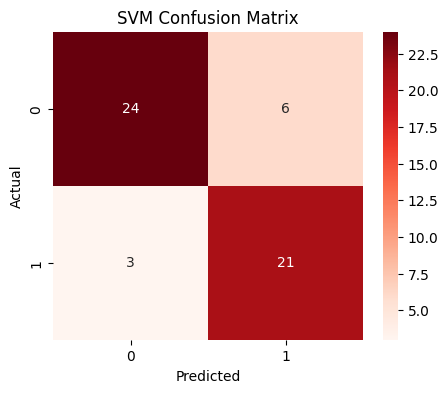

In [63]:
cm_svm = confusion_matrix(y_test, y_pred_svm)
print(cm_svm)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm_svm,
    annot=True,
    fmt='d',
    cmap='Reds'
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM Confusion Matrix")
plt.show()

In [64]:
precision_svm = precision_score(y_test, y_pred_svm, pos_label=1)
print("Precision:", precision_svm)

recall_svm = recall_score(y_test, y_pred_svm, pos_label=1)
print("Recall:", recall_svm)

f1_svm = f1_score(y_test, y_pred_svm, pos_label=1)
print("F1 Score:", f1_svm)

Precision: 0.7777777777777778
Recall: 0.875
F1 Score: 0.8235294117647058


In [65]:
from sklearn.model_selection import GridSearchCV
param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

grid_svm = GridSearchCV(
    estimator=SVC(random_state=42),
    param_grid=param_grid_svm,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_svm.fit(X_train_smote, y_train_smote)

GridSearchCV(cv=5, estimator=SVC(random_state=42), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto'],
                         'kernel': ['linear', 'rbf']},
             scoring='accuracy')

In [67]:
print("Best Parameters:")
print(grid_svm.best_params_)

print("Best CV Accuracy:")
print(grid_svm.best_score_)

best_svm = grid_svm.best_estimator_
best_pred_svm = best_svm.predict(X_test_scaled)
print("Final Accuracy:", accuracy_score(y_test, best_pred_svm))

Best Parameters:
{'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV Accuracy:
0.8291666666666666
Final Accuracy: 0.8333333333333334


In [68]:
print(classification_report(y_test, best_pred_svm))

              precision    recall  f1-score   support

           0       0.89      0.80      0.84        30
           1       0.78      0.88      0.82        24

    accuracy                           0.83        54
   macro avg       0.83      0.84      0.83        54
weighted avg       0.84      0.83      0.83        54



In [69]:
from sklearn.ensemble import VotingClassifier

In [70]:
voting_classifier = VotingClassifier(
    estimators=[
        ('lr', lr),
        ('knn', knn),
        ('dt', dt),
        ('rf', rf),
        ('svm', svm)
    ],
    voting='hard'
)

In [71]:
voting_classifier.fit(X_train_smote, y_train_smote)

VotingClassifier(estimators=[('lr', LogisticRegression(random_state=42)),
                             ('knn', KNeighborsClassifier()),
                             ('dt', DecisionTreeClassifier(random_state=42)),
                             ('rf', RandomForestClassifier(random_state=42)),
                             ('svm', SVC(random_state=42))])

In [72]:
y_pred_voting = voting_classifier.predict(X_test_scaled)

In [73]:
accuracy_voting = accuracy_score(y_test, y_pred_voting)
print("Accuracy:", accuracy_voting)

Accuracy: 0.8333333333333334


[[25  5]
 [ 4 20]]


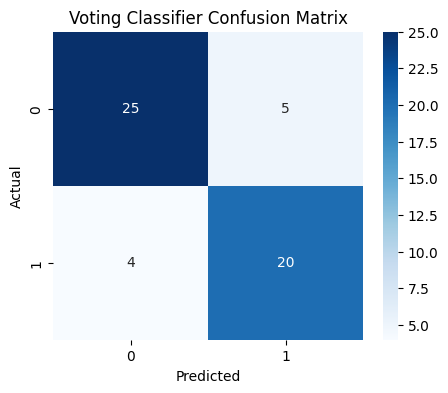

In [74]:
cm_voting = confusion_matrix(y_test, y_pred_voting)
print(cm_voting)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm_voting,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Voting Classifier Confusion Matrix")
plt.show()

In [75]:
precision_voting = precision_score(y_test, y_pred_voting)
print("Precision:", precision_voting)

recall_voting = recall_score(y_test, y_pred_voting)
print("Recall:", recall_voting)

f1_voting = f1_score(y_test, y_pred_voting)
print("F1 Score:", f1_voting)

Precision: 0.8
Recall: 0.8333333333333334
F1 Score: 0.8163265306122449


In [76]:
print(classification_report(y_test, y_pred_voting))

              precision    recall  f1-score   support

           0       0.86      0.83      0.85        30
           1       0.80      0.83      0.82        24

    accuracy                           0.83        54
   macro avg       0.83      0.83      0.83        54
weighted avg       0.83      0.83      0.83        54

